<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_AB_%D1%82%D0%B5%D1%81%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Учебный кейс: анализ A/B-теста**
*Шаблон для выполнения задания*

**Цель задания** — закрепить основные понятия и практические навыки анализа A/B-тестирования.

При выполнении заданий вам предстоит сформулировать статистические гипотезы, выбрать подходящие метрики и статистические тесты, рассчитать показатели эксперимента, интерпретировать значение p-value и определить типы статистических ошибок.

Результаты выполнения оформите в виде ответов на вопросы и, при необходимости, приложите код и расчёты.

## **Импорты библиотек**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, normaltest, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')

Для всех заданий, если не указано иное, используйте уровень значимости:

α = 0.05

> **Примечание**
>
> При необходимости самостоятельно выполните дополнительные импорты библиотек и функций, необходимых для проведения статистического анализа и решения заданий.

# **Задание 1. Формулирование гипотез**

**Описание кейса**

Интернет-магазин заметил, что многие пользователи добавляют товары в корзину, но не завершают покупку.

Команда продукта предположила, что пользователям не хватает информации о скидках и специальных предложениях.

Для решения этой проблемы было предложено разместить на странице товара заметный блок с информацией о действующих скидках.

Перед внедрением изменения для всех пользователей компания решила провести A/B-тестирование.

**Задание**

Предположите, что основной метрикой эксперимента является конверсия в покупку (Conversion Rate, CR).

Сформулируйте:

1. Гипотезу эксперимента в формате:
    Если мы [изменение], то [ожидаемый результат], потому что [обоснование].
2. Нулевую гипотезу (H₀).
3. Альтернативную гипотезу (H₁).

**Результат выполнения**

В ответе должны быть представлены:

* гипотеза эксперимента;
* нулевая гипотеза (H₀);
* альтернативная гипотеза (H₁).

> **Ваш ответ:**
Задание 1. Формулирование гипотез

**Гипотеза эксперимента:**  
Если мы разместим на странице товара заметный блок с информацией о действующих скидках, то конверсия в покупку (CR) увеличится, потому что пользователи получат больше информации о выгоде и будут чаще завершать покупку.

**Нулевая гипотеза (H₀):**  
CR_test = CR_control (размещение блока со скидками не влияет на конверсию)

**Альтернативная гипотеза (H₁):**  
CR_test > CR_control (размещение блока со скидками увеличивает конверсию)
>

# **Задание 2. Решение кейсов**

Для зачёта вам необходимо решить **как минимум один любой кейс** из трёх, представленных ниже. Вы можете решить и больше кейсов при желании. Это станет для вас дополнительной практикой в формулировании гипотез, работе с метрикой и интерпретации результатов теста.

## **Кейс 1. Анализ среднего чека**

### Описание кейса

Онлайн-сервис изменил страницу оплаты: упростил форму заказа, добавил подсказки по способам оплаты и сделал блок с итоговой суммой более заметным.

Команда предполагает, что новая версия страницы оплаты может увеличить средний чек пользователей.

Для проверки гипотезы был проведён A/B-тест:

- группа **A** — пользователи видели старую страницу оплаты;

- группа **B** — пользователи видели новую страницу оплаты.

Основная метрика эксперимента — **средний чек**.

---

### Генерация данных

В реальных проектах данные приходят из аналитической системы, но в этом задании мы сгенерируем учебный датасет.

In [ ]:
np.random.seed(42)

# Генерируем данные о среднем чеке для контрольной группы A
# Средний чек — 1200 рублей
# Стандартное отклонение — 300 рублей
# Количество пользователей — 1000

control = np.random.normal(
    loc=1200,
    scale=300,
    size=1000
)

# Генерируем данные о среднем чеке для тестовой группы B
# Предположим, что новая страница оплаты могла увеличить средний чек
# Средний чек — 1270 рублей
# Стандартное отклонение — 300 рублей
# Количество пользователей — 1000

test = np.random.normal(
    loc=1270,
    scale=300,
    size=1000
)

# Собираем данные в датафрейм

df = pd.DataFrame({
    "group": ["A"] * len(control) + ["B"] * len(test),
    "order_value": np.concatenate([control, test])
})

df.head()

,group,order_value
0,A,1349.014246
1,A,1158.520710
2,A,1394.306561
3,A,1656.908957
4,A,1129.753988


## Что нужно сделать

1. Проведите базовый анализ данных:
   - посмотрите первые строки датафрейма;
   - проверьте размер данных;
   - рассчитайте базовые статистики по группам.

2. Рассчитайте основную метрику эксперимента:
   - средний чек в группе A;
   - средний чек в группе B;
   - разницу между группами.

3. Визуализируйте распределение среднего чека:
   - постройте график среднего чека по группам;
   - постройте распределение значений `order_value` для групп A и B.

4. Проверьте, нужно ли выполнять проверку на нормальность распределения.
   - Если считаете, что проверка нужна, выполните её.
   - Если считаете, что проверка не обязательна, кратко объясните почему.

5. Сформулируйте гипотезы:
   - нулевую гипотезу H₀;
   - альтернативную гипотезу H₁.

6. Выберите и обоснуйте выбор статистического теста

7. Проведите статистический тест и найдите p-value.

8. Интерпретируйте результат:
   - сравните p-value с уровнем значимости α = 0.05;
   - сделайте вывод, есть ли статистически значимое различие;
   - напишите, можно ли рекомендовать новую страницу оплаты к внедрению.

---

In [ ]:
# Ваш код решения
# Базовый анализ данных
print("Размер данных:", df.shape)
print("\nБазовые статистики по группам:")
df.groupby("group")["order_value"].describe()


Размер данных: (2000, 2)

Базовые статистики по группам:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,1000.0,1205.799617,293.764781,227.619798,1005.722908,1207.590184,1394.383163,2355.819447
B,1000.0,1291.250871,299.236313,387.883410,1088.127493,1288.923140,1488.664653,2227.932270


In [ ]:
# Расчёт основной метрики
mean_A = df[df["group"] == "A"]["order_value"].mean()
mean_B = df[df["group"] == "B"]["order_value"].mean()
diff = mean_B - mean_A

print(f"Средний чек в группе A: {mean_A:.2f} руб.")
print(f"Средний чек в группе B: {mean_B:.2f} руб.")
print(f"Разница между группами: {diff:.2f} руб. ({(diff/mean_A)*100:.2f}%)")

Средний чек в группе A: 1205.80 руб.
Средний чек в группе B: 1291.25 руб.
Разница между группами: 85.45 руб. (7.09%)


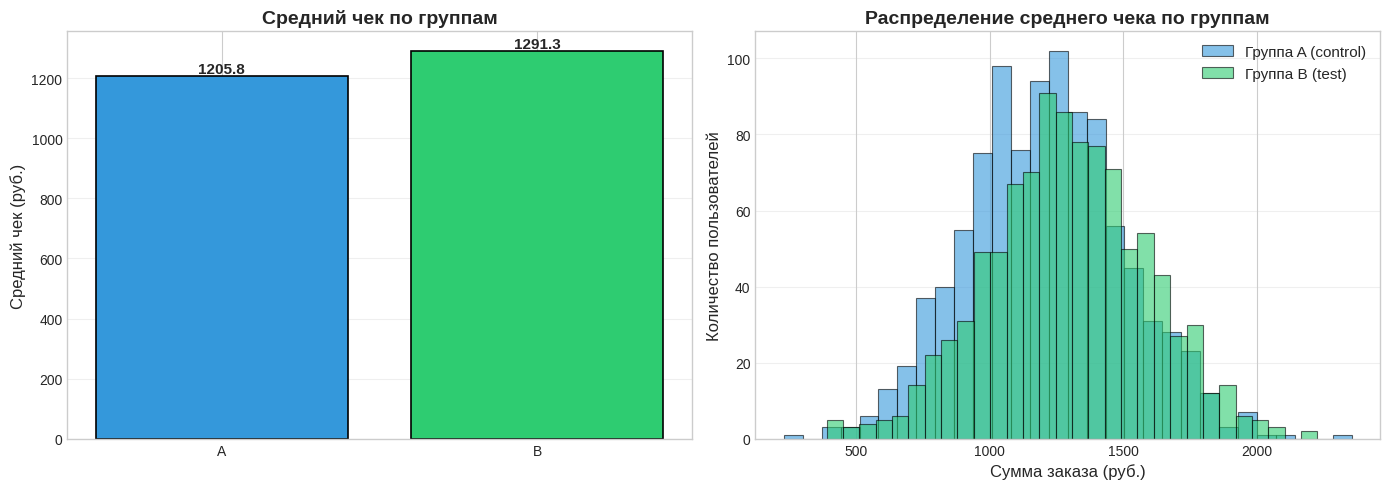

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средний чек по группам
groups = ["A", "B"]
means = [mean_A, mean_B]
axes[0].bar(groups, means, color=["#3498db", "#2ecc71"], edgecolor="black", linewidth=1.2)
axes[0].set_ylabel("Средний чек (руб.)", fontsize=12)
axes[0].set_title("Средний чек по группам", fontsize=14, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(means):
    axes[0].text(i, v + 10, f"{v:.1f}", ha="center", fontsize=11, fontweight="bold")

# График 2: Распределение значений
axes[1].hist(df[df["group"] == "A"]["order_value"], bins=30, alpha=0.6,
             label="Группа A (control)", color="#3498db", edgecolor="black", linewidth=0.8)
axes[1].hist(df[df["group"] == "B"]["order_value"], bins=30, alpha=0.6,
             label="Группа B (test)", color="#2ecc71", edgecolor="black", linewidth=0.8)
axes[1].set_xlabel("Сумма заказа (руб.)", fontsize=12)
axes[1].set_ylabel("Количество пользователей", fontsize=12)
axes[1].set_title("Распределение среднего чека по группам", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Проверка на нормальность
control_data = df[df["group"] == "A"]["order_value"]
test_data = df[df["group"] == "B"]["order_value"]

# Тест Шапиро-Уилка
stat_A, p_A = shapiro(control_data)
stat_B, p_B = shapiro(test_data)

print("Тест Шапиро-Уилка на нормальность:")
print(f"Группа A: статистика = {stat_A:.4f}, p-value = {p_A:.6f}")
print(f"Группа B: статистика = {stat_B:.4f}, p-value = {p_B:.6f}")

# Тест D'Agostino's K^2
stat_A2, p_A2 = normaltest(control_data)
stat_B2, p_B2 = normaltest(test_data)

print("\nТест D'Agostino's K^2 на нормальность:")
print(f"Группа A: статистика = {stat_A2:.4f}, p-value = {p_A2:.6f}")
print(f"Группа B: статистика = {stat_B2:.4f}, p-value = {p_B2:.6f}")

print("\nВывод: p-value > 0.05 → нет оснований отвергать гипотезу о нормальности")

Тест Шапиро-Уилка на нормальность:
Группа A: статистика = 0.9986, p-value = 0.627258
Группа B: статистика = 0.9988, p-value = 0.731193

Тест D'Agostino's K^2 на нормальность:
Группа A: статистика = 2.5755, p-value = 0.275888
Группа B: статистика = 0.6094, p-value = 0.737331

Вывод: p-value > 0.05 → нет оснований отвергать гипотезу о нормальности


In [ ]:
# Двухвыборочный t-тест
t_stat, p_value = ttest_ind(control_data, test_data, equal_var=True)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"\nУровень значимости α = 0.05")

if p_value < 0.05:
    print("Вывод: p-value < α → отвергаем H₀. Различие статистически значимо.")
    print("Рекомендация: новую страницу оплаты можно внедрять.")
else:
    print("Вывод: p-value ≥ α → не отвергаем H₀. Различие не значимо.")

t-статистика = -6.4441
p-value = 0.000000

Уровень значимости α = 0.05
Вывод: p-value < α → отвергаем H₀. Различие статистически значимо.
Рекомендация: новую страницу оплаты можно внедрять.


> **Примечание**
>
> Для удобства выполнения задания не обязательно размещать весь код в одной ячейке ноутбука.
>
> При необходимости рекомендуется разбивать решение на несколько логических этапов и использовать отдельные ячейки для:
>
> - анализа данных;
> - расчёта метрик;
> - визуализации результатов;
> - проверки статистических гипотез;
> - интерпретации полученных результатов.
>
> Текстовые пояснения, выводы и ответы на вопросы рекомендуется оформлять в отдельных Markdown-ячейках.
>

## **Кейс 2. Анализ конверсии пользователей**

### Описание кейса

Онлайн-сервис изменил форму регистрации пользователей.

Команда продукта предполагает, что новая форма регистрации стала более удобной и позволит большему количеству пользователей завершить регистрацию.

Для проверки гипотезы был проведён A/B-тест:

* группа A — пользователи видели старую форму регистрации;
* группа B — пользователи видели новую форму регистрации.

Для каждого пользователя известно, завершил он регистрацию или нет.

### Генерация данных

В реальных проектах данные приходят из аналитической системы, но в этом задании мы сгенерируем учебный датасет.

In [ ]:
np.random.seed(42)

# Контрольная группа

control = np.random.binomial(
    n=1,
    p=0.10,
    size=5000
)

# Тестовая группа

test = np.random.binomial(
    n=1,
    p=0.115,
    size=5000
)

# Формируем датафрейм

df2 = pd.DataFrame({
    "group": ["A"] * len(control) + ["B"] * len(test),
    "registered": np.concatenate([control, test])
})

df2.head()

,group,registered
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0


Описание данных

Поле registered принимает следующие значения:
* 1 — пользователь успешно завершил регистрацию;
* 0 — пользователь не завершил регистрацию.

## Что нужно сделать

1. Проведите первичный анализ данных:
   - изучите структуру датафрейма;
   - определите количество пользователей в каждой группе;
   - определите количество пользователей, завершивших регистрацию, в каждой группе.
2. Определите основную метрику эксперимента и рассчитайте её для:
    * группы A;
    * группы B.
3. Визуализируйте данные эксперимента:
   - постройте график, отражающий значение основной метрики в группах A и B;
   - при необходимости добавьте дополнительную визуализацию, которая поможет сравнить группы.
4. Определите, требуется ли в данном случае проверка нормальности распределения.
    * Если требуется — выполните её.
    * Если не требуется — объясните почему.
5. Сформулируйте:
    * нулевую гипотезу H₀;
    * альтернативную гипотезу H₁.
6. Выберите и обоснуйте выбор статистического теста
7. Проведите статистический тест и рассчитайте p-value.
8. Интерпретируйте результат:
    * сравните p-value с уровнем значимости α = 0.05;
    * определите, является ли результат статистически значимым;
    * сделайте вывод о влиянии новой формы регистрации на поведение пользователей.

In [ ]:
# Ваш код решения
# Первичный анализ
print("Размер данных:", df2.shape)
print("\nКоличество пользователей в каждой группе:")
print(df2["group"].value_counts())
print("\nКоличество пользователей, завершивших регистрацию:")
print(df2.groupby("group")["registered"].sum())

Размер данных: (10000, 2)

Количество пользователей в каждой группе:
group
A    5000
B    5000
Name: count, dtype: int64

Количество пользователей, завершивших регистрацию:
group
A    479
B    545
Name: registered, dtype: int64


In [ ]:
# Расчёт конверсии
n_A = len(df2[df2["group"] == "A"])
n_B = len(df2[df2["group"] == "B"])

success_A = df2[df2["group"] == "A"]["registered"].sum()
success_B = df2[df2["group"] == "B"]["registered"].sum()

cr_A = success_A / n_A
cr_B = success_B / n_B
diff_cr = cr_B - cr_A

print(f"Конверсия в группе A: {cr_A:.4f} ({cr_A*100:.2f}%)")
print(f"Конверсия в группе B: {cr_B:.4f} ({cr_B*100:.2f}%)")
print(f"Разница в конверсии: {diff_cr:.4f} ({diff_cr*100:.2f} п.п.)")
print(f"Относительный прирост: {(diff_cr/cr_A)*100:.2f}%")

Конверсия в группе A: 0.0958 (9.58%)
Конверсия в группе B: 0.1090 (10.90%)
Разница в конверсии: 0.0132 (1.32 п.п.)
Относительный прирост: 13.78%


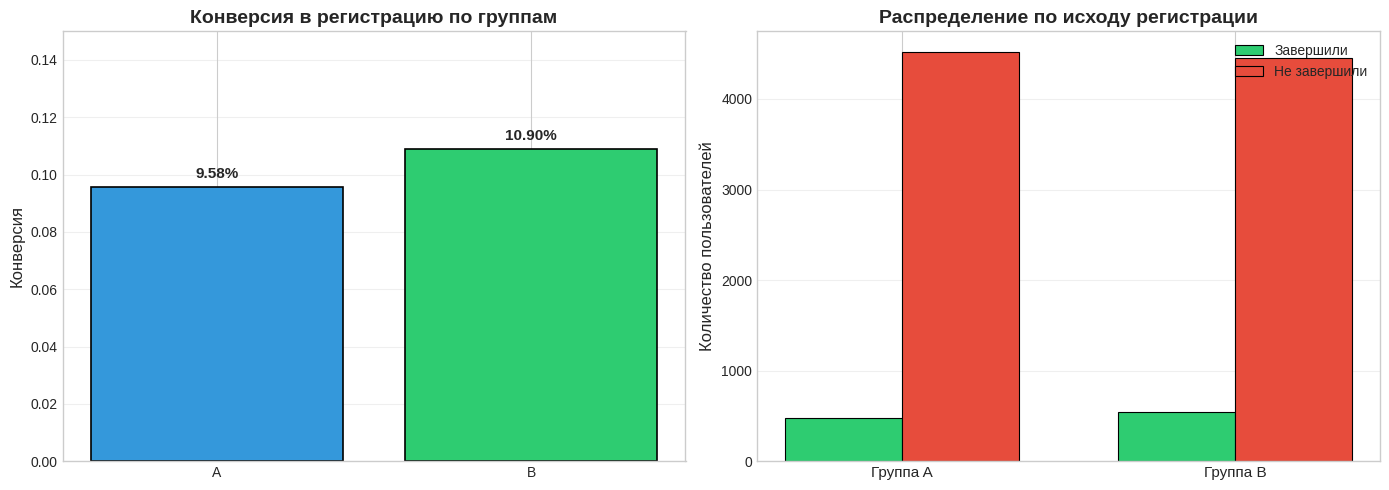

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Конверсия по группам
groups = ["A", "B"]
conversions = [cr_A, cr_B]
axes[0].bar(groups, conversions, color=["#3498db", "#2ecc71"], edgecolor="black", linewidth=1.2)
axes[0].set_ylabel("Конверсия", fontsize=12)
axes[0].set_title("Конверсия в регистрацию по группам", fontsize=14, fontweight="bold")
axes[0].set_ylim(0, 0.15)
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(conversions):
    axes[0].text(i, v + 0.003, f"{v*100:.2f}%", ha="center", fontsize=11, fontweight="bold")

# График 2: Распределение по исходу
completed = [success_A, success_B]
not_completed = [n_A - success_A, n_B - success_B]

x = np.arange(2)
width = 0.35

axes[1].bar(x - width/2, completed, width, label="Завершили",
            color="#2ecc71", edgecolor="black", linewidth=0.8)
axes[1].bar(x + width/2, not_completed, width, label="Не завершили",
            color="#e74c3c", edgecolor="black", linewidth=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(["Группа A", "Группа B"], fontsize=11)
axes[1].set_ylabel("Количество пользователей", fontsize=12)
axes[1].set_title("Распределение по исходу регистрации", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Двухвыборочный z-тест для пропорций
count = np.array([success_A, success_B])
nobs = np.array([n_A, n_B])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"z-статистика = {z_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"\nУровень значимости α = 0.05")

if p_value < 0.05:
    print("Вывод: p-value < α → отвергаем H₀. Различие статистически значимо.")
    print("Рекомендация: новую форму регистрации можно внедрять.")
else:
    print("Вывод: p-value ≥ α → не отвергаем H₀. Различие не значимо.")

z-статистика = -2.1770
p-value = 0.029483

Уровень значимости α = 0.05
Вывод: p-value < α → отвергаем H₀. Различие статистически значимо.
Рекомендация: новую форму регистрации можно внедрять.


> **Примечание**
>
> Для удобства выполнения задания не обязательно размещать весь код в одной ячейке ноутбука.
>
> При необходимости рекомендуется разбивать решение на несколько логических этапов и использовать отдельные ячейки для:
>
> - анализа данных;
> - расчёта метрик;
> - визуализации результатов;
> - проверки статистических гипотез;
> - интерпретации полученных результатов.
>
> Текстовые пояснения, выводы и ответы на вопросы рекомендуется оформлять в отдельных Markdown-ячейках.
>

## **Кейс 3. Проверка влияния персональных рекомендаций на средний чек**

### Описание кейса

Интернет-магазин внедрил блок персональных рекомендаций товаров на странице оформления заказа.

Команда продукта предполагает, что рекомендации помогут пользователям находить дополнительные товары и увеличат сумму покупки.

Основная цель эксперимента — команда продукта ожидает, что рекомендации увеличат средний чек пользователей.

Для проверки гипотезы был проведён A/B-тест:

- группа **A** — пользователи видели старую версию страницы оформления заказа;
- группа **B** — пользователи видели страницу с блоком персональных рекомендаций.

---



## Генерация данных

В реальных проектах данные поступают из аналитической системы, но в этом задании мы сгенерируем учебный датасет.

In [ ]:
np.random.seed(42)

# Контрольная группа

control = np.random.normal(
    loc=1500,
    scale=350,
    size=1200
)

# Тестовая группа

test = np.random.normal(
    loc=1580,
    scale=350,
    size=1200
)

# Формируем датафрейм

df = pd.DataFrame({
    "group": ["A"] * len(control) + ["B"] * len(test),
    "order_value": np.concatenate([control, test])
})

df.head()

,group,order_value
0,A,1673.849954
1,A,1451.607495
2,A,1726.690988
3,A,2033.060450
4,A,1418.046319


## Что нужно сделать

1. Проведите базовый анализ данных:
   - изучите структуру датафрейма;
   - определите размер выборки в каждой группе;
   - рассчитайте основные статистики для групп A и B.

2. Рассчитайте основную метрику эксперимента:
   - средний чек в группе A;
   - средний чек в группе B;
   - разницу между группами.

3. Визуализируйте данные:
   - постройте график среднего чека по группам;
   - визуализируйте распределение значений среднего чека.

4. Определите, требуется ли проверка нормальности распределения.
   - Если требуется — выполните её.
   - Если не требуется — объясните почему.

5. Сформулируйте:
   - нулевую гипотезу H₀;
   - альтернативную гипотезу H₁.

6. Выберите и обоснуйте выбор статистического теста

7. Проведите статистический тест и рассчитайте p-value.

8. Интерпретируйте результат:
   - сравните p-value с уровнем значимости α = 0.05;
   - определите, есть ли статистически значимый эффект;
   - сделайте вывод о возможности внедрения персональных рекомендаций.

In [ ]:
# Ваш код решения
# Базовый анализ данных

# Структура датафрейма
print("Структура датафрейма:")
print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Типы данных:\n{df.dtypes}")

# Размер выборки в каждой группе
print("\nРазмер выборки в каждой группе:")
print(df["group"].value_counts())

# Основные статистики
print("\nОсновные статистики для групп A и B:")
df.groupby("group")["order_value"].describe()


Структура датафрейма:
Размер: (2400, 2)
Колонки: ['group', 'order_value']
Типы данных:
group           object
order_value    float64
dtype: object

Размер выборки в каждой группе:
group
A    1200
B    1200
Name: count, dtype: int64

Основные статистики для групп A и B:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,1200.0,1513.433776,345.938374,365.556431,1281.248387,1516.906151,1736.604920,2848.456022
B,1200.0,1588.628073,344.311403,523.170745,1355.301841,1584.309495,1815.425955,2697.587649


In [ ]:
# Расчёт основной метрики
mean_A = df[df["group"] == "A"]["order_value"].mean()
mean_B = df[df["group"] == "B"]["order_value"].mean()
diff = mean_B - mean_A

print(f"Средний чек в группе A: {mean_A:.2f} руб.")
print(f"Средний чек в группе B: {mean_B:.2f} руб.")
print(f"Разница между группами: {diff:.2f} руб. ({(diff/mean_A)*100:.2f}%)")

Средний чек в группе A: 1513.43 руб.
Средний чек в группе B: 1588.63 руб.
Разница между группами: 75.19 руб. (4.97%)


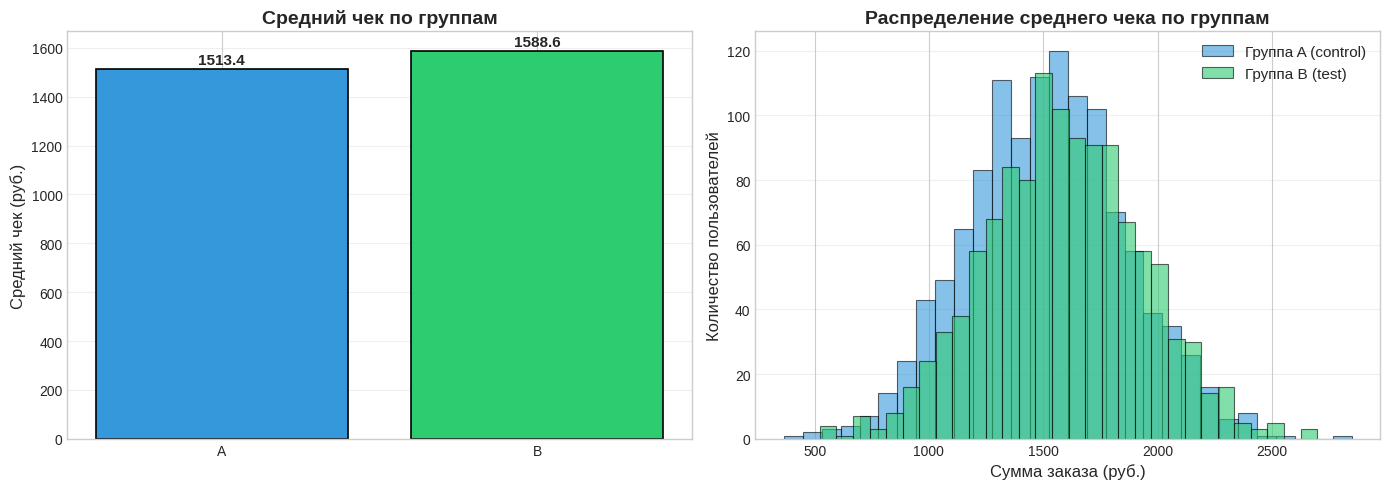

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средний чек по группам
groups = ["A", "B"]
means = [mean_A, mean_B]
axes[0].bar(groups, means, color=["#3498db", "#2ecc71"], edgecolor="black", linewidth=1.2)
axes[0].set_ylabel("Средний чек (руб.)", fontsize=12)
axes[0].set_title("Средний чек по группам", fontsize=14, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(means):
    axes[0].text(i, v + 20, f"{v:.1f}", ha="center", fontsize=11, fontweight="bold")

# График 2: Распределение значений среднего чека
axes[1].hist(df[df["group"] == "A"]["order_value"], bins=30, alpha=0.6,
             label="Группа A (control)", color="#3498db", edgecolor="black", linewidth=0.8)
axes[1].hist(df[df["group"] == "B"]["order_value"], bins=30, alpha=0.6,
             label="Группа B (test)", color="#2ecc71", edgecolor="black", linewidth=0.8)
axes[1].set_xlabel("Сумма заказа (руб.)", fontsize=12)
axes[1].set_ylabel("Количество пользователей", fontsize=12)
axes[1].set_title("Распределение среднего чека по группам", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
control_data = df[df["group"] == "A"]["order_value"]
test_data = df[df["group"] == "B"]["order_value"]

# Тест Шапиро-Уилка
stat_A, p_A = shapiro(control_data)
stat_B, p_B = shapiro(test_data)

print("Тест Шапиро-Уилка на нормальность:")
print(f"Группа A: статистика = {stat_A:.4f}, p-value = {p_A:.6f}")
print(f"Группа B: статистика = {stat_B:.4f}, p-value = {p_B:.6f}")

# Тест D'Agostino's K^2
stat_A2, p_A2 = normaltest(control_data)
stat_B2, p_B2 = normaltest(test_data)

print("\nТест D'Agostino's K^2 на нормальность:")
print(f"Группа A: статистика = {stat_A2:.4f}, p-value = {p_A2:.6f}")
print(f"Группа B: статистика = {stat_B2:.4f}, p-value = {p_B2:.6f}")

print("\nВывод: p-value > 0.05 → нет оснований отвергать гипотезу о нормальности")
print("Примечание: при n=1200 в каждой группе t-тест робастен к отклонениям от нормальности")

Тест Шапиро-Уилка на нормальность:
Группа A: статистика = 0.9992, p-value = 0.894629
Группа B: статистика = 0.9993, p-value = 0.936034

Тест D'Agostino's K^2 на нормальность:
Группа A: статистика = 0.7204, p-value = 0.697538
Группа B: статистика = 0.2874, p-value = 0.866157

Вывод: p-value > 0.05 → нет оснований отвергать гипотезу о нормальности
Примечание: при n=1200 в каждой группе t-тест робастен к отклонениям от нормальности


## Гипотезы

**H₀ (нулевая гипотеза):**  
Средний чек в группе B равен среднему чеку в группе A.  
μ_B = μ_A

**H₁ (альтернативная гипотеза):**  
Средний чек в группе B отличается от среднего чека в группе A.  
μ_B ≠ μ_A

## Выбор статистического теста

**Тест:** Двухвыборочный t-тест Стьюдента (независимые выборки)

**Обоснование:**
- Сравниваются средние значения непрерывной метрики (средний чек)
- Выборки независимы (разные пользователи в группах A и B)
- Распределение близко к нормальному (подтверждено тестами)
- Дисперсии групп схожи (scale=350 для обеих групп)

In [ ]:
# Двухвыборочный t-тест
t_stat, p_value = ttest_ind(control_data, test_data, equal_var=True)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"\nУровень значимости α = 0.05")

t-статистика = -5.3368
p-value = 0.000000

Уровень значимости α = 0.05


In [ ]:
# Интерпретация результата
alpha = 0.05

print("=" * 60)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТА")
print("=" * 60)
print(f"p-value = {p_value:.6f}")
print(f"α = {alpha}")

if p_value < alpha:
    print(f"\n✓ p-value < α → ОТВЕРГАЕМ H₀")
    print("✓ Различие в среднем чеке статистически значимо")
    print(f"✓ Средний чек в группе B выше на {diff:.2f} руб. ({(diff/mean_A)*100:.2f}%)")
    print("\nРЕКОМЕНДАЦИЯ: Персональные рекомендации можно внедрять")
else:
    print(f"\n✗ p-value ≥ α → НЕ ОТВЕРГАЕМ H₀")
    print("✗ Различие в среднем чеке не статистически значимо")
    print("\nРЕКОМЕНДАЦИЯ: Требуются дополнительные исследования")

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТА
p-value = 0.000000
α = 0.05

✓ p-value < α → ОТВЕРГАЕМ H₀
✓ Различие в среднем чеке статистически значимо
✓ Средний чек в группе B выше на 75.19 руб. (4.97%)

РЕКОМЕНДАЦИЯ: Персональные рекомендации можно внедрять


> **Примечание**
>
> Для удобства выполнения задания не обязательно размещать весь код в одной ячейке ноутбука.
>
> При необходимости рекомендуется разбивать решение на несколько логических этапов и использовать отдельные ячейки для:
>
> - анализа данных;
> - расчёта метрик;
> - визуализации результатов;
> - проверки статистических гипотез;
> - интерпретации полученных результатов.
>
> Текстовые пояснения, выводы и ответы на вопросы рекомендуется оформлять в отдельных Markdown-ячейках.
>

# **Задание 3. Ошибки первого и второго рода**

## Описание кейса

Аналитик провёл несколько A/B-тестов и подготовил отчёт по результатам экспериментов.

Ваша задача — определить, была ли допущена статистическая ошибка в каждой ситуации и указать её тип.

---

## Ситуация А

Компания протестировала новый дизайн кнопки оформления заказа.

Статистический тест показал значимые различия между группами, поэтому изменение внедрили для всех пользователей.

Через несколько недель после запуска дополнительный анализ показал, что новый дизайн не оказывает влияния на конверсию.

---

## Ситуация Б

Компания протестировала новую систему персональных рекомендаций товаров.

Статистический тест показал отсутствие значимых различий между группами, поэтому изменение решили не внедрять.

Позже эксперимент повторили на большем объёме данных и выяснили, что рекомендации действительно увеличивают средний чек.

---

## Что нужно сделать

Для каждой ситуации:

1. Определите, была ли допущена статистическая ошибка.
2. Укажите тип ошибки:
   - ошибка первого рода (Type I Error);
   - ошибка второго рода (Type II Error).
3. Объясните свой выбор.
4. Кратко опишите, в чём заключается данная ошибка.

> **Ваш ответ:**
## Задание 3. Ошибки первого и второго рода

### Ситуация А

**1. Была ли допущена ошибка?** Да

**2. Тип ошибки:** Ошибка первого рода (Type I Error)

**3. Объяснение:**
- Тест показал значимые различия → изменение внедрили
- Последующий анализ показал, что эффекта нет → H₀ была верна
- Компания ошибочно отвергла верную нулевую гипотезу

**4. В чём заключается ошибка:**
Ошибка I рода — это ложноположительный результат. Мы делаем вывод о наличии эффекта, когда в реальности его нет. Вероятность такой ошибки равна уровню значимости α (в данном случае 5%).

---

### Ситуация Б

**1. Была ли допущена ошибка?** Да

**2. Тип ошибки:** Ошибка второго рода (Type II Error)

**3. Объяснение:**
- Тест не показал значимых различий → изменение не внедрили
- Позже выяснилось, что эффект есть → H₀ была неверна
- Компания ошибочно не отвергла неверную нулевую гипотезу

**4. В чём заключается ошибка:**
Ошибка II рода — это ложноотрицательный результат. Мы делаем вывод об отсутствии эффекта, когда в реальности он есть. Вероятность такой ошибки обозначается β. Мощность теста (1-β) — вероятность правильно обнаружить существующий эффект.

---

### Сводная таблица

| Решение теста | H₀ верна (эффекта нет) | H₀ неверна (эффект есть) |
|---------------|------------------------|--------------------------|
| Отвергнуть H₀ | **Ошибка I рода** | Верное решение |
| Не отвергнуть H₀ | Верное решение | **Ошибка II рода** |

- **Ситуация А:** Ошибка I рода — внедрили неработающее изменение
- **Ситуация Б:** Ошибка II рода — не внедрили работающее изменение
>